# N2 · CFG 强度消融 (Classifier-Free Guidance)

> 配套 13.3-L3 · guidance scale 从 0 到 4, 看生成从「随便落」收敛到「精确落在指定类」。
> 亲手验证 CFG 旋钮的「保真 vs 多样」权衡 (接 9.4)。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import numpy as np, torch
import dit
print('就绪')

就绪


## 1. 训练 DiT (训练时随机丢条件, 为 CFG 准备, L3)

In [2]:
torch.manual_seed(0)
x, y = dit.make_class_blobs(n_per=200, seed=1)
model = dit.build_dit()
losses, sched = dit.train_dit(model, x, y, epochs=700, p_uncond=0.15)
print(f"训练 loss {losses[0]:.3f} → {losses[-1]:.3f} (含 15% 无条件, CFG 需要)")

训练 loss 1.631 → 0.148 (含 15% 无条件, CFG 需要)


## 2. CFG 强度消融: guidance 0→4, 生成类别 0

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


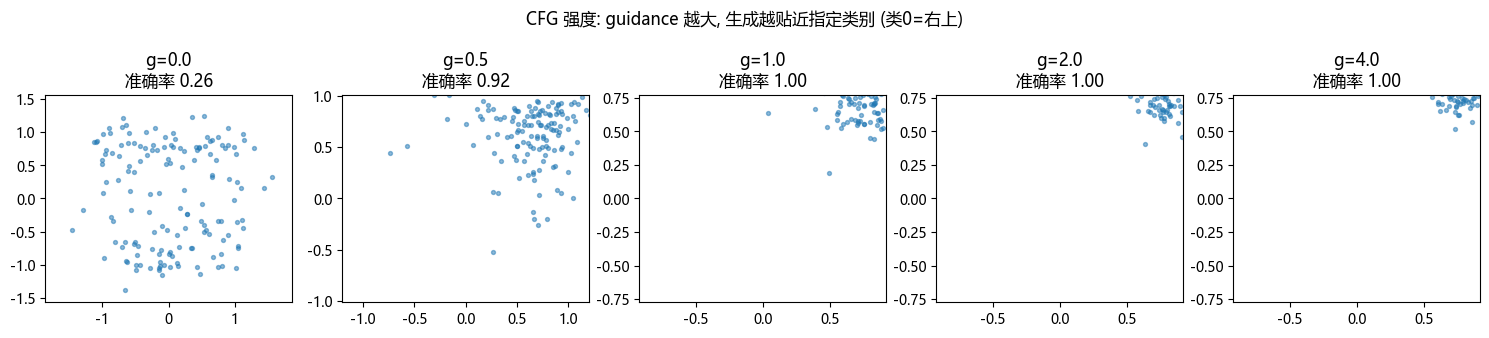

guidance vs 类别准确率: {0.0: 0.26, 0.5: 0.92, 1.0: 1.0, 2.0: 1.0, 4.0: 1.0}


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
guidances = [0.0, 0.5, 1.0, 2.0, 4.0]
fig, axes = plt.subplots(1, len(guidances), figsize=(15,3.4))
accs = []
for g, ax in zip(guidances, axes):
    s = dit.sample(model, sched, cls=0, n=150, guidance=g, seed=4)
    acc = dit.class_accuracy(s, 0); accs.append(acc)
    ax.scatter(s[:,0], s[:,1], s=8, alpha=0.5)
    ax.set_title(f'g={g}\n准确率 {acc:.2f}'); ax.axis('equal'); ax.set_xlim(-1.2,1.2); ax.set_ylim(-1.2,1.2)
plt.suptitle('CFG 强度: guidance 越大, 生成越贴近指定类别 (类0=右上)'); plt.tight_layout(); plt.show()
print("guidance vs 类别准确率:", {g:round(a,2) for g,a in zip(guidances,accs)})

## 3. CFG 曲线 + 解读 (L3 的保真 vs 多样权衡)

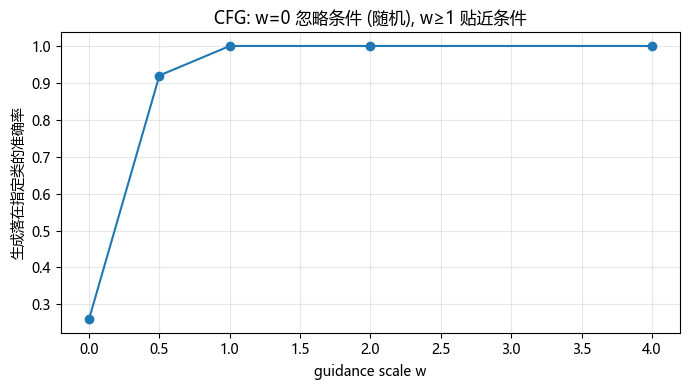

解读 (L3):
  w=0: 无条件, 随便落 (准确率≈随机)
  w=1: 标准条件生成
  w>1: 更贴合条件 (文生图常用 7); 但真实里太大会过饱和/失真 (保真 vs 多样, 该消融 9.4)


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
plt.figure(figsize=(7,4))
plt.plot(guidances, accs, 'o-')
plt.xlabel('guidance scale w'); plt.ylabel('生成落在指定类的准确率')
plt.title('CFG: w=0 忽略条件 (随机), w≥1 贴近条件'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("解读 (L3):")
print("  w=0: 无条件, 随便落 (准确率≈随机)")
print("  w=1: 标准条件生成")
print("  w>1: 更贴合条件 (文生图常用 7); 但真实里太大会过饱和/失真 (保真 vs 多样, 该消融 9.4)")

## 4. 反思 (13.3 收口)

你亲手验证了 CFG: guidance scale 控制「生成多贴近条件」。带走:
- CFG = 同时学有条件/无条件去噪, 生成时放大「条件方向」; w 是那个旋钮 (你用 SD 调的 CFG scale)。
- 保真 vs 多样权衡: w 大更贴合但过饱和, 小更自然但可能不贴 (该消融, 9.4)。
- **文生图 = 文本塔(M10.1) + cross-attn(M10.2) + DiT + CFG + latent(L2) = Stable Diffusion**, 你懂了每块。

> **M13.3 收口**: 扩散的机制(13.1)+速度(13.2)+骨架控制(13.3) = 懂 Stable Diffusion 怎么造。
> 交棒 13.4: 扩散从图扩到**视频** (加时间维, 接你 M10.5 视频 token)。下一专题 `video-generation`。